# Test Signal for Initial Synchronization

This notebook synthesizes a test signal for initial synchronization. The generated signal includes a known preamble and a payload of random bits for testing the synchronization algorithms.

The channel introduces a delay, amplitude and phase changes, a constant frequency offset, and additive noise.

In [378]:
## Boilerplate instructions for importing NumPy and Matplotlib
# Import NumPy
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
sns_context = "notebook"
sns.set_theme(context=sns_context, style="ticks")

# proper labeling of plots
from matplotlib.ticker import EngFormatter

In [379]:
from dc_632_26.sources import RandomBitSource
from dc_632_26.pulses import SqrtRaisedCosinePulse
from dc_632_26.constellations import standard_constellation
from dc_632_26.modulation import modulation
from dc_632_26.pulse_shaper import PulseShaper

## Transmitted Signal

**Notes:**
- The transmitted signal consists of a known training sequence (preamble) followed by a payload of random bits.
- SRRC pulse shaping is used for both the training sequence and the payload.
- The preamble is BPSK modulated, the payload is QPSK modulated
- The signal is oversampled 32 times per symbol period to enable fractional delays; it will be reduced to 8x oversampling during channel simulation.

In [380]:
## Signal parameters
# preamble - this is a length 31 M-sequence
preamble_bits = np.array([1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 
                          0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 
                          1, 1, 0, 1, 0], dtype=np.uint8)
preamble_constellation = standard_constellation.BPSK
preamble_symbols = modulation(preamble_bits, preamble_constellation)

# payload - 1000 random bits
payload_bits = RandomBitSource().get_bits(1000)
payload_constellation = standard_constellation.QPSK
payload_symbols = modulation(payload_bits, payload_constellation)

# pulse shaping
fsT = 32
pulse = SqrtRaisedCosinePulse(num_samples=10*fsT, oversamp=fsT, alpha=0.5)
ps = PulseShaper(pulse, fsT)

bb_sig = ps.generate_waveform(np.concatenate((preamble_symbols, payload_symbols)))



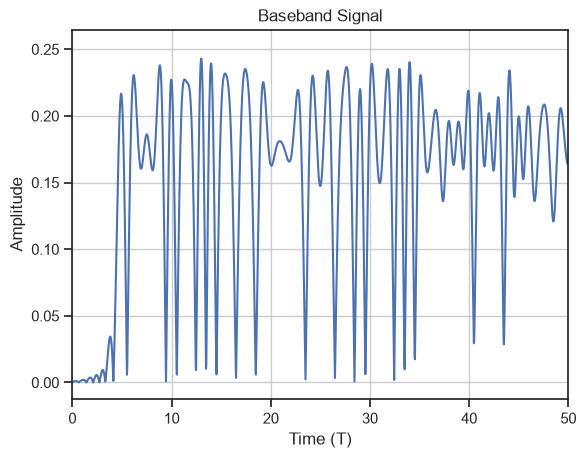

In [381]:
plt.plot(np.arange(len(bb_sig))/fsT, np.abs(bb_sig))
plt.xlabel('Time (T)')
plt.ylabel('Amplitude')
plt.title('Baseband Signal')
plt.grid(True)
plt.xlim(0, 50)
plt.show()

## Simulating transmission

Our simulated transmission will include:

* AWGN
* a delay of 102 samples
* amplitude and phase change
* reduction of the sample rate from 32 to 8; note that 102 is not evenly divisible by 8 so that we incur a fractional delay
* frequency offset is not simulated at this time

In [382]:
## channel parameters
delay_samples = 102
ds_factor = 4       # down-sample by 4
fsT_r = fsT // ds_factor

# frequency offset per sample, phase change is 0.1*2*pi over course of preamble
df = 0 #0.1/(len(preamble_symbols) * fsT) 
X = 0.5*np.exp(1j*np.pi/4) # amplitude and phase

# delay by pre-pending zeros
rr = np.concatenate(( np.zeros(delay_samples), 
                     X * bb_sig * np.exp(2j * np.pi * df * np.arange(len(bb_sig))), 
                     np.zeros(delay_samples) ))

# down-sample
rr = rr[::ds_factor]
fsT_r = fsT // ds_factor

SNR_dB = 20
SNR = 10**(SNR_dB/10)
noise_var = preamble_constellation.Es / SNR 

## the down-sampled signal amplitude is increased, to compensate for "energy" lost
# when discarding samples
rr = np.sqrt(ds_factor)*rr + np.sqrt(0.5 * noise_var) * (np.random.randn(len(rr)) + 1j*np.random.randn(len(rr))) 

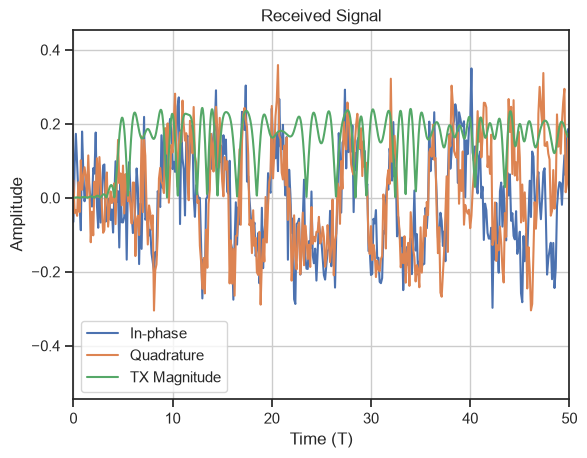

In [383]:
plt.plot(np.arange(len(rr))/fsT_r, rr.real, label="In-phase")
plt.plot(np.arange(len(rr))/fsT_r, rr.imag, label="Quadrature")
plt.plot(np.arange((len(bb_sig)))/fsT, 
         np.abs(bb_sig), label="TX Magnitude")

plt.xlabel('Time (T)')
plt.ylabel('Amplitude')
plt.title('Received Signal')
plt.xlim(0, 50)
plt.grid(True)
plt.legend(loc='lower left')
plt.show()

For reference: With the above parameters, the first sample of the preamble is the 25-th or 26-th (102/4) sample of the received signal. 

## Receiver Processing

The goal is to develop a full receiver that can accurately detect and synchronize with the preamble of the received signal, and subsequently demodulate the transmitted data. To help this goal, the `PolyPhaseCorrelator` class below computes all quantities necessary for detecting the preamble and determining the optimal sampling phase. Note that this correlator assumes that the received signal is passed through a pulse matched filter.

The remaining tasks to complete the receiver include:
- Implementing the preamble detection logic using the output of the `PolyPhaseCorrelator`. This involves replacing the peak search over the entire signal with detection using a suitably chosen threshold. This process should account for the (likely) case that the first breach of the threshold does not correspond to the peak of the correlator output; that is likely to occur a few samples after the first breach. The detection logic should output:
    + the estimated sampling phase
    + the estimated symbol index of the preamble peak
    + the correlator output at the detected preamble peak
- Estimation of additional channel parameters once the preamble has been detected, including:
    + the channel complex gain (amplitude and phase)
    + the frequency offset (be explicit, if this is estimated in Hz or as normalized frequency. For a normalized frequency, there are two options: cycles per sample or cycles per symbol)
    + the noise variance (at the matched filter output)
- Applying the estimated channel parameters to the received signal for proper synchronization. Upon detection of the preamble and estimation of the channel parameters, the receiver must correct the received signal to compensate these channel effects.
    + Note: determining the correct phase requires a little thought, as it depends on the phase of the channel complex gain, the frequency offset, and the delays introduced by channel and matched filter.
- Demodulating the received data symbols after synchronization. The correct phase of the matched filter outputs, with corrected amplitude frequency and phase, must be demodulated starting with the first symbol after the preamble.

Ultimately, all of these pieces should be integrated into a complete receiver chain; that is probably best realized as a single class. It should:
* toggle between two states:
    + preamble detection and synchronization
    + data demodulation
* at the transition from synchronization to data demodulation, the various parameter estimates should be computed
* estimates of the channel parameters (complex gain, frequency offset, noise variance) should be used to correct the received signal before demodulation
* the correct samples must be fed to the demodulator: correct first sample and correct sampling phase
* after demodulation, the receiver transitions back to the preamble detection and synchronization state for the next frame. At the transition, the correlator is reset.

**Hint:** In the received signal, the preamble starts at the 26-th sample. Probably more importantly, after the signal is passed through the matched filter, the first sample of the preamble is the 105-th sample of the matched filter output. The first sample of the data is the 353-rd sample of the matched filter output (105 + 31*8 = 353). 

You can use this information: 
* to verify the correctness of your preamble detection and synchronization logic and 
* to develop and test the estimation of the channel parameters. 
* Even the demodulation process can leverage this information to locate the start of the data symbols.

In [384]:
class PolyPhaseCorrelator:
    """Sequential Polyphase Correlator for signal synchronization.
    
    This class implements a sequential polyphase correlator for signal synchronization. It 
    processes the output of the (pulse) matched filter and computes the correlation with the known preamble sequence for each sampling phase. Sequential processing means that the correlator updates its output sample by sample, rather than computing the correlation over the entire signal at once. This enables real-time synchronization and permits transitioning to demodulation as soon as synchronization is achieved.

    Attributes:
    -----------
    preamble_symbols : np.ndarray
        The known preamble sequence used for correlation.
    num_phases : int
        The number of sampling phases for the polyphase correlator; this equals the oversampling factor of the received signal.
    n_phase : int
        The current sampling phase index.
    n_symbol : int
        The current symbol index.

    Methods:
    --------
    __init__(preamble_symbols, num_phases)
        Initialize the correlator with the given preamble and number of phases.
    reset()
        Reset the internal state of the correlator.
    update(matched_filter_output)
        Update the correlator with a new matched filter output sample and return the correlation and norm-squared.
    correlate()
        Compute the correlation for the current buffer state.
    sq_magnitude_mf_out()
        Compute the norm-squared of the matched filter outputs for the current phase.
    buffer(n_phase):
        Return the last `len(preamble_symbols)` samples for the specified phase, starting with the oldest sample.
    
    """
    def __init__(self, preamble_symbols, num_phases):
        self.preamble_symbols = preamble_symbols
        self.num_phases = num_phases

        ## internal state
        # ring buffer for each phase; stores the last `len(preamble_symbols)` samples
        self._buffer = np.zeros((num_phases, len(preamble_symbols)), dtype=complex)
        self.n_phase = -1
        self.n_symbol = -1

    def __repr__(self):
        return f"PolyPhaseCorrelator(preamble_symbols={self.preamble_symbols}, num_phases={self.num_phases})"

    def reset(self):
        """Reset the internal buffers of the correlator.
        
        Resets the internal state of the correlator, including the buffer, phase, and symbol counters. Invoke this function before starting a new synchronization process.
        """
        self._buffer.fill(0)
        self.n_phase = -1
        self.n_symbol = -1

    def update(self, matched_filter_output):
        """Update the inner state of the correlator with a new matched filter output sample.

        Parameters:
        -----------
        matched_filter_output : complex
            The new sample from the matched filter output.

        Returns:
        --------
        tuple
            A tuple containing the correlation value and the norm-squared of the matched filter outputs for the current phase.
        """
        # Advance the phase and symbol counters
        self.n_phase = (self.n_phase + 1) % self.num_phases
        if self.n_phase == 0:
            self.n_symbol = (self.n_symbol + 1)

        # ring buffer for each phase; new sample overwrites the oldest one in a circular manner
        self._buffer[self.n_phase, 
                     self.n_symbol % len(self.preamble_symbols)] = matched_filter_output
        
        # return the correlation resulting from new MF output
        return self.correlate(), self.sq_magnitude_mf_out()

    def correlate(self):
        """Compute the correlation for the current buffer state.
        
        Returns:
        --------
        complex
            The correlation value after insertion of the newest matched filter output sample.
        """

        # the buffer contents is rotated; the position of the oldest sample in the buffer
        # is equal to (self.n_symbol + 1) % len(self.preamble_symbols). That position needs
        # to be circularly shifted to the front.
        n_oldest = (self.n_symbol + 1) % len(self.preamble_symbols)
        return np.sum(np.roll(self._buffer[self.n_phase, :], -n_oldest) * 
                      np.conj(self.preamble_symbols))

    def sq_magnitude_mf_out(self):
        """compute the norm-squared of the matched filter outputs for the current phase.
        
        Returns:
        --------
        float
            The norm-squared of the matched filter outputs for the current phase.
        """
        return np.sum(np.abs(self._buffer[self.n_phase, :])**2)

    def buffer(self, n_phase:int):
        """Retrieve the contents of the buffer for the specified phase, with the oldest sample rotated to the front so that the buffer appears in chronological order.
        
        Parameters:
        -----------
        n_phase : int
            The phase index for which to retrieve the buffer contents.

        Returns:
        --------
        np.ndarray
            The buffer contents for the specified phase, with the oldest sample rotated to the front.
        """
        n_oldest = (self.n_symbol + 1) % len(self.preamble_symbols)

        return np.roll(self._buffer[self.n_phase, :], -n_oldest)

    

### How to use the `PolyPhaseCorrelator`

The `PolyPhaseCorrelator` is used to perform sequential polyphase correlation for signal synchronization. It processes the output of a matched filter and computes the correlation with a known preamble sequence for each sampling phase. This allows for real-time synchronization and enables transitioning to demodulation as soon as synchronization is achieved.

The correlator operates on the output of the pulse matched filter. It is fed one sample at a time, updating its internal state and computing the correlation after the insertion of each new sample.

As such the correlator should operate in a loop, continuously feeding it new matched filter output samples until the preamble is detected. At that point, parameters should be estimated and the synchronization process can transition to demodulation.

The example below demonstrates the use of the correlator for computing the cross-correlation between the matched filter output and the known preamble sequence for the entire signal, i.e., there is no detection logic or parameter estimation.

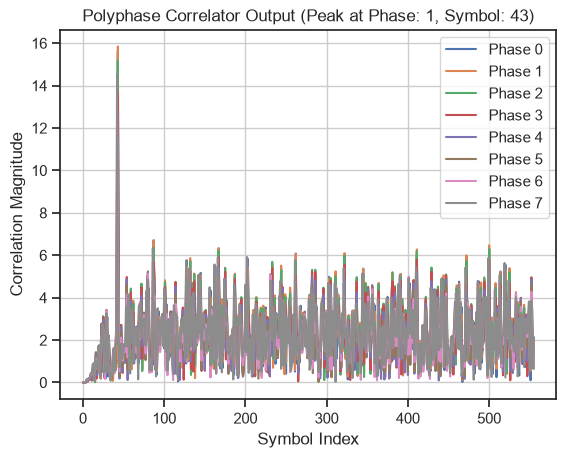

In [385]:
## matched filter output
# we need a different pulse than the transmitter because the oversampling factor is different
mf_hh = SqrtRaisedCosinePulse(num_samples=10*fsT_r, oversamp=fsT_r, alpha=0.5)._generate_samples()
mf_out = np.convolve(rr, np.flipud(mf_hh.conj()))

# prepare for the polyphase correlation loop
num_phases = fsT_r
num_symbols = len(mf_out) // num_phases
corrs = np.zeros((num_phases, num_symbols), dtype=complex)
mags = np.zeros((num_phases, num_symbols), dtype=float)

# instantiate the polyphase correlator
pp_corr = PolyPhaseCorrelator(preamble_symbols, num_phases=num_phases)

for k in range(num_symbols):
    for p in range(num_phases):
        sample = mf_out[k*num_phases + p]
        corr, mag = pp_corr.update(sample)
        corrs[p, k] = corr
        mags[p, k] = mag

# locate peak correlation
m_ind = np.argmax(np.abs(corrs), axis=1)
p_ind = np.argmax([np.abs(corrs[i, m_ind[i]]) for i in range(num_phases)])
k_ind = m_ind[p_ind]

for p in range(num_phases):
    plt.plot(np.abs(corrs[p, :]), label=f'Phase {p}')
plt.xlabel('Symbol Index')
plt.ylabel('Correlation Magnitude')
plt.title(f'Polyphase Correlator Output (Peak at Phase: {p_ind}, Symbol: {k_ind})')
plt.legend()
plt.grid()
plt.show()

**Parameter Estimation**

In [386]:
class ParameterEstimation:
    """Parameter Estimation of the detected Preamble.

    This class implements methods to estimate the channel complex gain, 
    the frequency offset, and the noise variance of the detected preamble. 

    Attributes:
    -----------
    preamble : np.ndarray
        The known preamble symbols sequence used for correlation.
    div : int
        The number of segments the preamble is split into for frequency offset estimation.
    """
    
    def __init__(self, preamble, divisions):
        '''Initialize the estimator with the known preamble and the number of segments for frequency offset estimation '''
        self.preamble = preamble
        self.div = divisions

    def _innerProduct(self, rxd, pream):
        '''Compute the discrete inner product between a received segment and a known (preamble) segment'''
        return np.sum(rxd * np.conj(pream))

    def complexGainEstimator(self, Rn, sn):
        '''Estimate the complex channel gain (amplitude and phase) from a received segment and its corresponding known segment.'''
        numerator = self._innerProduct(Rn, sn)
        denominator = self._innerProduct(sn, sn)
        return numerator / denominator

    def frequencyOffset(self, Rn, sn):
        """
        Returns frequency offset in normalized frequency: cycles/symbol
        Estimates the frequency offset by splitting the received and known sequences into `div`
        segments, estimating one complex gain per segment, and fitting phase versus segment center using an average.
        """

        symbols_per_segment = len(sn) // self.div
        freq_offset_estimates = []

        for segment_index in range(self.div - 1):
            start_index = segment_index * symbols_per_segment

            received_segment_a = Rn[start_index : start_index + symbols_per_segment]
            received_segment_b = Rn[start_index + symbols_per_segment : start_index + 2 * symbols_per_segment]

            known_segment_a = sn[start_index : start_index + symbols_per_segment]
            known_segment_b = sn[start_index + symbols_per_segment : start_index + 2 * symbols_per_segment]

            segment_gain_a = self.complexGainEstimator(received_segment_a, known_segment_a)
            segment_gain_b = self.complexGainEstimator(received_segment_b, known_segment_b)

            phase_change = np.angle(segment_gain_b * np.conj(segment_gain_a))
            delta_f = phase_change / (2 * np.pi * symbols_per_segment)

            freq_offset_estimates.append(delta_f)

        return np.mean(freq_offset_estimates)


    def noiseVariance(self, Rn, cpx_gain_est=None):
        '''
        Estimate the noise variance at the matched filter output using the residual error after
        frequency correction and complex gain estimation.
        '''
        sn = self.preamble

        if cpx_gain_est is None:
            cpx_gain_est = self.complexGainEstimator(Rn, sn)

        residual = Rn - cpx_gain_est * sn
        noise_var = np.mean(np.abs(residual) ** 2)

        return noise_var



**Testing Parameter Estimation**

**Hint:** In the received signal, the preamble starts at the 26-th sample. Probably more importantly, after the signal is passed through the matched filter, the first sample of the preamble is the 105-th sample of the matched filter output. The first sample of the data is the 353-rd sample of the matched filter output (105 + 31*8 = 353). 

You can use this information: 
* to verify the correctness of your preamble detection and synchronization logic and 
* to develop and test the estimation of the channel parameters. 
* Even the demodulation process can leverage this information to locate the start of the data symbols

In [387]:
Rn = mf_out[105 :105 + len(preamble_symbols)*fsT_r : fsT_r] # received preamble
ps = preamble_symbols

PE = ParameterEstimation(ps, divisions=5)

freq_offset = PE.frequencyOffset(Rn, ps)

n = np.arange(len(Rn))
Rn_corrected = Rn * np.exp(-1j*2*np.pi*freq_offset*n)
complex_gain = PE.complexGainEstimator(Rn_corrected, ps)

noise_var_est = PE.noiseVariance(Rn)

# Printing the Estimates
print("Gain estimate:", complex_gain, "| magnitude:", abs(complex_gain), "phase:", np.angle(complex_gain))
print(f"Frequency offset estimate: {freq_offset} cycles/symbol")
print("Noise variance estimate:", noise_var_est)

# Printing the True Channel Parameters
print("\n--- True channel parameters ---")
print("True gain:", X, "| magnitude:", abs(X), "phase:", np.angle(X))
print(f"True frequency offset: {df * fsT} cycles/symbol")  # df is cycles/sample at the fsT=32 rate
print("True noise variance (pre-matched-filter, in rr):", noise_var)

# Printing the Relative Error beteen the two above
print("\n--- Relative error ---")
true_df = df * fsT
#gain_mag_err = abs(abs(complex_gain_new) - abs(X)) / abs(X) * 100
#gain_phase_err = abs(np.angle(complex_gain_new) - np.angle(X)) / abs(np.angle(X)) * 100
freq_err = abs(freq_offset - true_df) / abs(true_df) * 100
noise_err = abs(noise_var_est - noise_var) / abs(noise_var) * 100

# print(f"Gain magnitude relative error: {gain_mag_err:.2f}%")
#print(f"Gain phase relative error: {gain_phase_err:.2f}%")
print(f"Frequency offset relative error: {freq_err:.2f}%")
# Note: not a true apples-to-apples comparison, since noise_var is pre-matched-filter
# and noise_var_est is post-matched-filter -- expect this one to be large/not meaningful.
print(f"Noise variance relative error: {noise_err:.2f}% (pre- vs post-matched-filter, not directly comparable)")


Gain estimate: (0.34223429484636964+0.3796628251513862j) | magnitude: 0.5111439849699143 phase: 0.8371992376967797
Frequency offset estimate: -0.00014328755718874466 cycles/symbol
Noise variance estimate: 0.009581424994121273

--- True channel parameters ---
True gain: (0.3535533905932738+0.35355339059327373j) | magnitude: 0.5 phase: 0.7853981633974482
True frequency offset: 0 cycles/symbol
True noise variance (pre-matched-filter, in rr): 0.01

--- Relative error ---
Frequency offset relative error: inf%
Noise variance relative error: 4.19% (pre- vs post-matched-filter, not directly comparable)


/var/folders/31/lyq1hfb96pl5cvx1gnm2fbzw0000gn/T/ipykernel_66823/2722015297.py:30: RuntimeWarning: divide by zero encountered in scalar divide
  freq_err = abs(freq_offset - true_df) / abs(true_df) * 100


In [ ]:
def correctSymbols(Rn, freq_offset, complex_gain, start_index=0):
    n = np.arange(start_index, start_index + len(Rn))
    return Rn * np.exp(-1j * 2 * np.pi * freq_offset * n) / complex_gain

def gainMagnitudeErrorPercent(estimated_complex_gain, true_complex_gain):
    return abs(abs(estimated_complex_gain) - abs(true_complex_gain)) / abs(true_complex_gain) * 100

def gainPhaseErrorDegrees(estimated_complex_gain, true_complex_gain):
    phase_difference = np.angle(estimated_complex_gain) - np.angle(true_complex_gain)
    wrapped_phase_difference = np.angle(np.exp(1j * phase_difference))
    return abs(np.degrees(wrapped_phase_difference))

def frequencyOffsetErrorPercent(estimated_freq_offset, true_freq_offset):
    return abs(estimated_freq_offset - true_freq_offset) / abs(true_freq_offset) * 100

preamble_start = 105
data_start = 353
received_preamble_symbols = mf_out[preamble_start:preamble_start + len(preamble_symbols) * fsT_r:fsT_r]
known_preamble_symbols = preamble_symbols
num_divisions = 4

parameter_estimator = ParameterEstimation(known_preamble_symbols, num_divisions)
estimated_freq_offset = parameter_estimator.frequencyOffset(received_preamble_symbols, known_preamble_symbols)
frequency_corrected_preamble = correctSymbols(received_preamble_symbols, estimated_freq_offset, 1.0, start_index=0)
estimated_complex_gain = parameter_estimator.complexGainEstimator(frequency_corrected_preamble, known_preamble_symbols)
estimated_noise_var = parameter_estimator.noiseVariance(frequency_corrected_preamble, estimated_complex_gain)
corrected_preamble_symbols = frequency_corrected_preamble / estimated_complex_gain
residual_metric = np.mean(np.abs(corrected_preamble_symbols - known_preamble_symbols) ** 2)



In [389]:

# ── True channel parameters ────────────────────────────────────────────────────
true_complex_gain = X
true_freq_offset = df * fsT
true_noise_var = noise_var

# ── Correct the data symbols using estimated and true parameters ───────────────
received_data_symbols = mf_out[data_start::fsT_r]
data_symbol_start = (data_start - preamble_start) // fsT_r

estimated_corrected_data_symbols = correctSymbols(received_data_symbols, estimated_freq_offset, estimated_complex_gain, start_index=data_symbol_start)
true_corrected_data_symbols = correctSymbols(received_data_symbols, true_freq_offset, true_complex_gain, start_index=data_symbol_start)

# ── Relative error ─────────────────────────────────────────────────────────────
gain_mag_err_pct = gainMagnitudeErrorPercent(estimated_complex_gain, true_complex_gain)
gain_phase_err_deg = gainPhaseErrorDegrees(estimated_complex_gain, true_complex_gain)
freq_err_pct = frequencyOffsetErrorPercent(estimated_freq_offset, true_freq_offset)

/var/folders/31/lyq1hfb96pl5cvx1gnm2fbzw0000gn/T/ipykernel_66823/68310625.py:15: RuntimeWarning: divide by zero encountered in scalar divide
  return abs(estimated_freq_offset - true_freq_offset) / abs(true_freq_offset) * 100



=== Estimated vs True ===
Gain:  0.3405+0.3812j | mag 0.5111 | phase 48.22 deg
True:  0.3536+0.3536j | mag 0.5000 | phase 45.00 deg
Freq:  -0.000190 vs 0.000000 cycles/symbol
Noise: 0.009591 vs 0.010000 (not directly comparable)

=== Error ===
Gain mag: 2.23% | Gain phase: 3.22 deg | Freq: inf%
Residual metric: 3.671022e-02


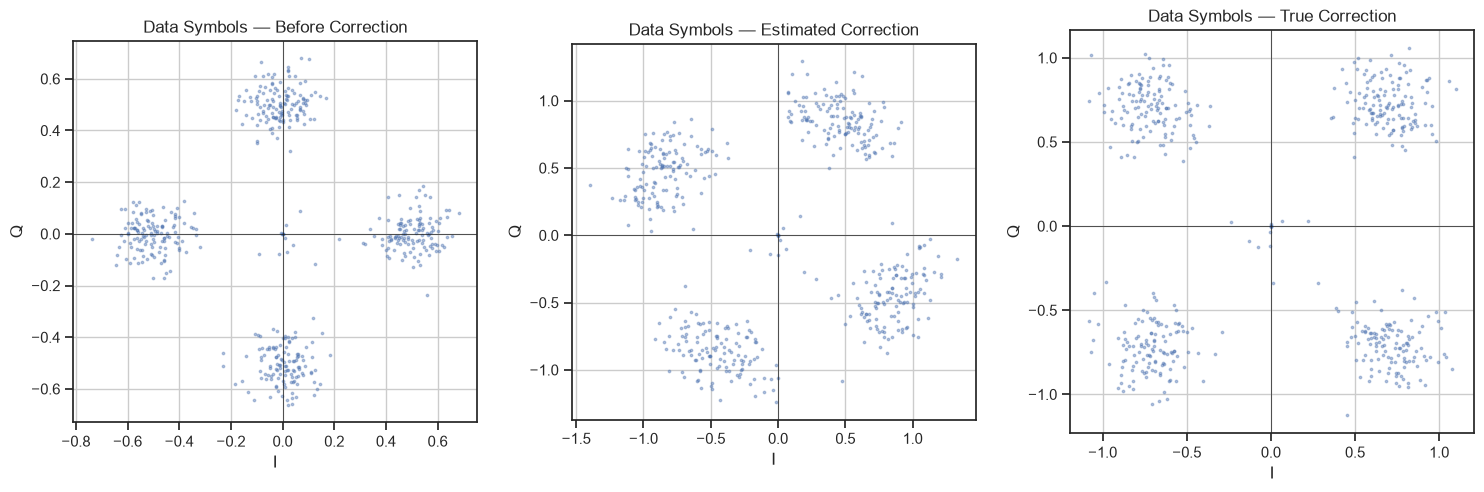

In [390]:

print("\n=== Estimated vs True ===")
print(f"Gain:  {estimated_complex_gain:.4f} | mag {abs(estimated_complex_gain):.4f} | phase {np.degrees(np.angle(estimated_complex_gain)):.2f} deg")
print(f"True:  {true_complex_gain:.4f} | mag {abs(true_complex_gain):.4f} | phase {np.degrees(np.angle(true_complex_gain)):.2f} deg")
print(f"Freq:  {estimated_freq_offset:.6f} vs {true_freq_offset:.6f} cycles/symbol")
print(f"Noise: {estimated_noise_var:.6f} vs {true_noise_var:.6f} (not directly comparable)")

print("\n=== Error ===")
print(f"Gain mag: {gain_mag_err_pct:.2f}% | Gain phase: {gain_phase_err_deg:.2f} deg | Freq: {freq_err_pct:.2f}%")
print(f"Residual metric: {residual_metric:.6e}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plots = [
    (received_data_symbols, "Before Correction"),
    (estimated_corrected_data_symbols, "Estimated Correction"),
    (true_corrected_data_symbols, "True Correction"),
]

for ax, (symbols, title) in zip(axes, plots):
    ax.scatter(symbols.real, symbols.imag, s=3, alpha=0.4)
    ax.set_title(f"Data Symbols — {title}")
    ax.set_xlabel("I")
    ax.set_ylabel("Q")
    ax.axhline(0, color='k', lw=0.5)
    ax.axvline(0, color='k', lw=0.5)
    ax.set_aspect('equal')
    ax.grid()

plt.tight_layout()
plt.show()